That statement is about **stacking (model ensembling)** and is emphasizing a very important rule:

### In plain terms:

When you do stacking—i.e., using predictions from several “base models” as features for a “meta model”—you **must use the exact same train/validation splits (folds) for all base models**.

### Why?

1. **Avoid data leakage:**
   If one model uses one set of folds and another model uses a different set, the meta model might see predictions from a model that was trained on **the same data it is trying to predict**. This leaks information and makes your meta model overfit.

2. **Consistency for meta-features:**
   The meta model is trained on predictions from the base models for **out-of-fold samples only**. If the folds don’t match, the predictions will be misaligned, and the meta model will get “garbled” features.

3. **Technical detail:**
   If your folds differ, your out-of-fold predictions will not correspond to the same validation rows across models, breaking the assumption that every row in your meta-training set represents an unseen prediction.

---

### Example:

Suppose 5-fold CV:

| Fold | Base Model A Prediction | Base Model B Prediction |
| ---- | ----------------------- | ----------------------- |
| 1    | valid rows              | different valid rows    |
| 2    | …                       | …                       |

If the rows are different, the meta model will mix predictions from rows that **don’t correspond**, ruining stacking.

✅ **Rule of thumb:**

> Use **exactly the same KFold split** for all base models when generating out-of-fold predictions for stacking.

---

If you want, I can make a **small diagram showing the correct stacking fold alignment**, which usually makes this much clearer. Do you want me to?




## **2️⃣ Fold columns for stacking – explained clearly**

Think of stacking like this:

1. You have **base models** (Model A, Model B…).
2. You want to **train each model on part of the data and predict on the rest** (out-of-fold).
3. Later, a **meta-model** uses the predictions from base models as features.

### Example:

```text
Original dataset (X_train):
Index  Feature1  Feature2  Target
0      1.2       3.4       0
1      2.1       1.5       1
2      0.7       0.3       0
3      1.5       2.2       1
4      0.9       0.8       0
```

If you do 2-fold CV:

```python
splitter.create_fold_column(df=X_train, y=y_train, column_name="fold")
```

You might get:

```text
Index  Feature1  Feature2  Target  fold
0      1.2       3.4       0       0
1      2.1       1.5       1       0
2      0.7       0.3       0       1
3      1.5       2.2       1       1
4      0.9       0.8       0       1
```

* **Fold column tells you:** “this row belongs to fold 0 or fold 1”
* When generating OOF predictions, you only train the model on **other folds** and predict for the **current fold**.
* This ensures **no data leakage** and all OOF predictions are correct for stacking.

---

### **3️⃣ Your questions about features vs rows**

* **Rows unchanged, features added → safe to reuse old folds.**
* **Rows changed → regenerate folds.**
* **Meta-model requires OOF predictions aligned with rows**. Fold columns help with that alignment.

---

If you want, I can make a **small visual diagram showing exactly how fold columns work for stacking**, which usually makes it click instantly.

Do you want me to make that diagram?


In [ ]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import time

# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms

# from sklearnex import unpatch_sklearn
# unpatch_sklearn()

# -------------------------------
# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')
id = 'PassengerId'
test_ids = X_test[id]
X_test.drop(columns=[id], inplace=True)

# Flatten target if needed
# Map target to numeric
target = 'Survived'

y_train_numeric = y_train[target]


num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd

def evaluate_train(model, X_train, y_train):
    y_train_pred = model.predict(X_train)

    print("TRAINING RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"ACCURACY SCORE: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")


Number of classes: 2
X_train shape: (891, 13)
X_test shape: (418, 13)


# Voting

In [41]:
import glob
import os
SUB_DIR = "submission"

files = sorted(glob.glob(os.path.join(SUB_DIR, "*.csv")))
print(f"Loaded {len(files)} files")

dfs = {}
for f in files:
    name = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(f)
    dfs[name] = df

list(dfs.keys())

Loaded 27 files


['adaboost_optuna_submission',
 'bagged_knn_optuna_submission',
 'baggedtree_optuna_submission',
 'base_models_hard_voting_submission',
 'base_models_soft_voting_submission',
 'extratrees_optuna_submission',
 'gradientboost_optuna_submission',
 'hgb_optuna_submission',
 'hgb_w_RSearchCV_submission',
 'lgb2leaves_augm_optuna_submission',
 'lgb_optuna_submission',
 'lgb_w_RSearchCV_submission',
 'lgbm_optuna_submission',
 'optuna_random_forest_submission',
 'optuna_xgb_submission',
 'pycaret_blended_top4',
 'pycaret_single_best_model',
 'pycaret_stacked_top4',
 'rf_optuna_submission',
 'rf_w_RSearchCV_submission',
 'stacked_submission',
 'stacking_submission',
 'submission_xgb_optuna',
 'voting_submission',
 'votting_after_begging_optuna_submission',
 'xgb_optuna_submission',
 'xgb_w_RSearchCV_submission']

In [48]:
import pandas as pd
import glob
import os

SUB_DIR = "submission"
files = sorted(glob.glob(os.path.join(SUB_DIR, "*.csv")))

dfs = {}

def detect_cols(df):
    # ID column: common Kaggle patterns
    id_candidates = ["PassengerId", "id", "Id", "ID"]
    id_col = next((c for c in id_candidates if c in df.columns), df.columns[0])

    # prediction column = any non-id numeric column
    pred_cols = [
        c for c in df.columns
        if c != id_col and pd.api.types.is_numeric_dtype(df[c])
    ]

    if len(pred_cols) != 1:
        raise ValueError(f"Cannot uniquely detect prediction column: {df.columns}")

    return id_col, pred_cols[0]

for f in files:
    name = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(f)

    id_col, pred_col = detect_cols(df)

    dfs[name] = df[[id_col, pred_col]].rename(
        columns={pred_col: name}
    )

print(f"Loaded {len(dfs)} submissions safely")


Loaded 27 submissions safely


In [49]:
sample = next(iter(dfs.values()))
print(sample.head())

id_col = sample.columns[0]
pred_col = sample.columns[1]


   PassengerId  adaboost_optuna_submission
0          892                           0
1          893                           0
2          894                           0
3          895                           0
4          896                           0


In [51]:
# Use first file's ID as index
ids = dfs[next(iter(dfs))].iloc[:, 0]

pred_matrix = pd.DataFrame(index=ids)

for name, df in dfs.items():
    # After renaming, the prediction column IS name
    pred_matrix[name] = df[name].values

print(pred_matrix.shape)
pred_matrix.head()


(418, 27)


,adaboost_optuna_submission,bagged_knn_optuna_submission,baggedtree_optuna_submission,base_models_hard_voting_submission,base_models_soft_voting_submission,extratrees_optuna_submission,gradientboost_optuna_submission,hgb_optuna_submission,hgb_w_RSearchCV_submission,lgb2leaves_augm_optuna_submission,...,pycaret_stacked_top4,rf_optuna_submission,rf_w_RSearchCV_submission,stacked_submission,stacking_submission,submission_xgb_optuna,voting_submission,votting_after_begging_optuna_submission,xgb_optuna_submission,xgb_w_RSearchCV_submission
PassengerId,,,,,,,,,,,,,,,,,,,,,
892,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.151778,0,0,0,0,0
893,0,0,1,0,0,1,0,0,1,0,...,0,1,0,0,0.395618,0,0,0,0,0
894,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.164911,0,0,0,0,0
895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.162589,0,0,0,0,0
896,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0.328807,0,0,0,0,0


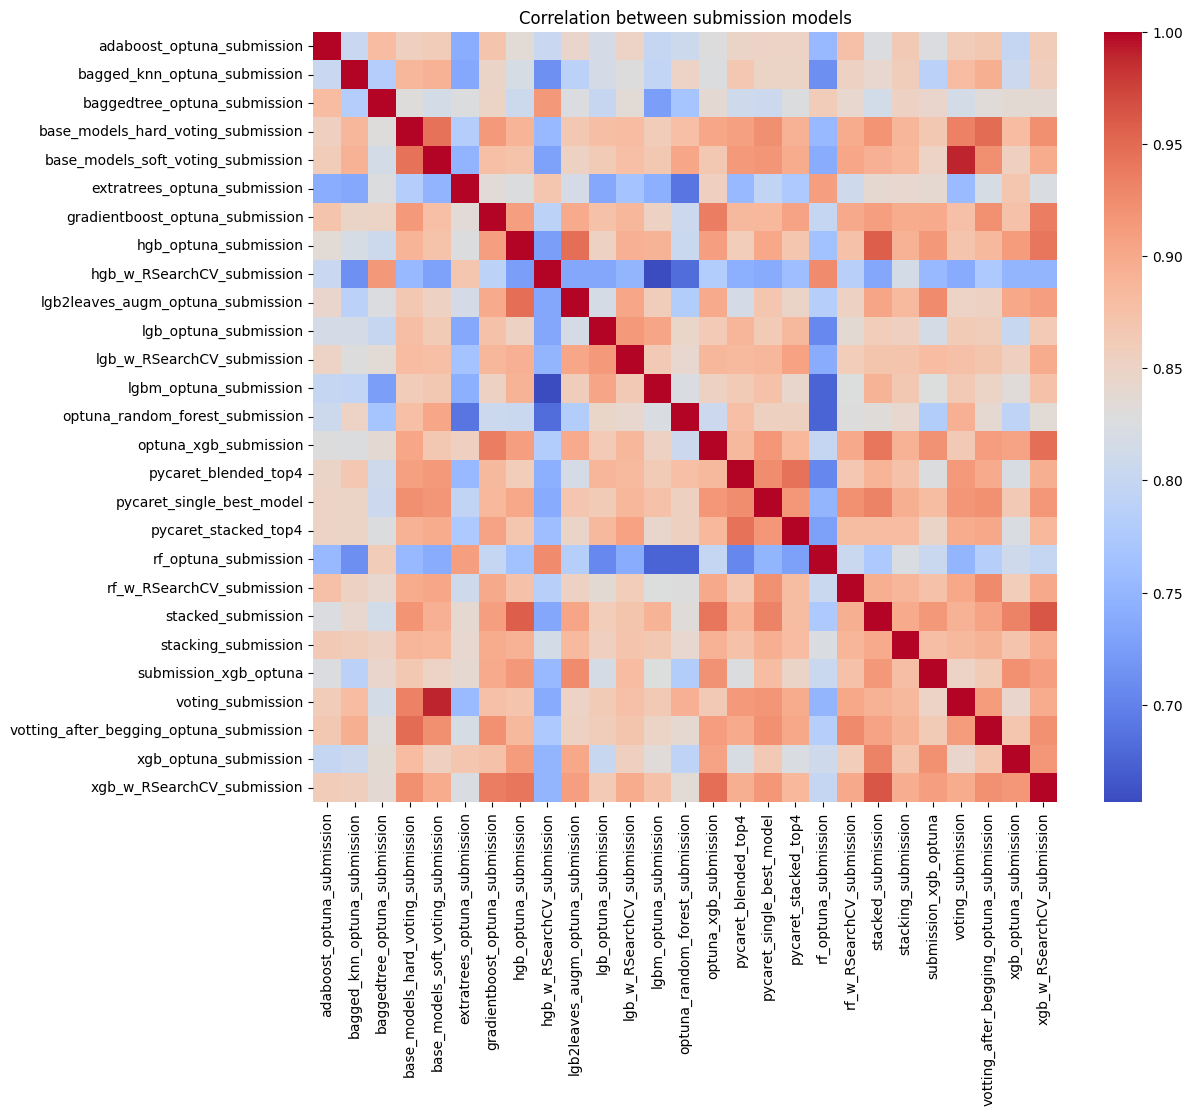

In [52]:
corr = pred_matrix.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation between submission models")
plt.show()


# Simple average (baseline ensemble)

In [54]:
avg_pred = pred_matrix.mean(axis=1)

avg_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': avg_pred
})

avg_submission.to_csv("ensamble/ensemble_avg.csv", index=False)
print("Average ensemble saved ✅")


Average ensemble saved ✅


# Rank averaging (robust to calibration issues)

In [55]:
from scipy.stats import rankdata
rank_pred = np.zeros_like(pred_matrix.values)

for i, col in enumerate(pred_matrix.columns):
    rank_pred[:, i] = rankdata(pred_matrix[col].values)

rank_avg = rank_pred.mean(axis=1)

rank_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': rank_avg
})
rank_submission.to_csv("ensamble/ensemble_rank_avg.csv", index=False)
print("Rank average ensemble saved ✅")


Rank average ensemble saved ✅


# Weighted averaging (strong models weighted more)

In [56]:
weights = {}
for col in pred_matrix.columns:
    if "xgb" in col.lower() or "lgb" in col.lower() or "hgb" in col.lower():
        weights[col] = 1.5  # tree boosters get more weight
    else:
        weights[col] = 1.0  # everything else

W = np.array([weights[c] for c in pred_matrix.columns])
weighted_pred = (pred_matrix.values * W).sum(axis=1) / W.sum()

weighted_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': weighted_pred
})
weighted_submission.to_csv("ensamble/ensemble_weighted.csv", index=False)
print("Weighted ensemble saved ✅")


Weighted ensemble saved ✅


# Voting

In [ ]:
import numpy as np
from scipy.stats import mode

# Convert to 0/1
binary_preds = (pred_matrix.values >= 0.5).astype(int)

# Hard vote
hard_vote_pred = mode(binary_preds, axis=1).mode.flatten()

hard_vote_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': hard_vote_pred
})
hard_vote_submission.to_csv("ensemble/ensemble_hard_vote.csv", index=False)
print("Hard voting ensemble saved ✅")


# Soft vote
soft_vote_pred = pred_matrix.mean(axis=1)

soft_vote_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': soft_vote_pred
})
soft_vote_submission.to_csv("ensamble/ensemble_soft_vote.csv", index=False)
print("Soft voting ensemble saved ✅")



Hard voting ensemble saved ✅


In [58]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import os

# -------------------------------
# Config
# -------------------------------
ENSEMBLE_DIR = "ensemble"
os.makedirs(ENSEMBLE_DIR, exist_ok=True)
THRESHOLD = 0.5  # for converting probabilities to 0/1

# pred_matrix = your loaded predictions DataFrame
# Each column = a model, index = id

# -------------------------------
# Detect binary vs probability predictions
# -------------------------------
def is_binary(column):
    unique_vals = np.unique(column)
    return set(unique_vals).issubset({0,1})

binary_flags = pred_matrix.apply(is_binary)
print(f"Binary models detected: {binary_flags.sum()} / {pred_matrix.shape[1]}")

# -------------------------------
# Hard Voting
# -------------------------------
# Convert probabilities >= THRESHOLD to 0/1 for non-binary models
binary_preds = np.where(pred_matrix.values >= THRESHOLD, 1, 0)

hard_vote_pred = mode(binary_preds, axis=1).mode.flatten()

hard_vote_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': hard_vote_pred
})
hard_vote_submission.to_csv(os.path.join(ENSEMBLE_DIR, "ensemble_hard_vote.csv"), index=False)
print("✅ Hard voting ensemble saved")

# -------------------------------
# Soft Voting
# -------------------------------
# Simple average of all models
soft_vote_pred = pred_matrix.mean(axis=1)

soft_vote_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': soft_vote_pred
})
soft_vote_submission.to_csv(os.path.join(ENSEMBLE_DIR, "ensemble_soft_vote.csv"), index=False)
print("✅ Soft voting ensemble saved")

# -------------------------------
# Weighted Voting (advanced)
# -------------------------------
# Assign weights automatically based on model type
weights = np.array([1.5 if any(x in c.lower() for x in ["xgb","lgb","hgb","rf","extra"]) else 1.0 for c in pred_matrix.columns])

# Weighted soft vote
weighted_soft_vote = (pred_matrix.values * weights).sum(axis=1) / weights.sum()
weighted_soft_vote_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': weighted_soft_vote
})
weighted_soft_vote_submission.to_csv(os.path.join(ENSEMBLE_DIR, "ensemble_weighted_soft_vote.csv"), index=False)
print("✅ Weighted soft voting ensemble saved")

# Weighted hard vote
weighted_binary_preds = np.where(weighted_soft_vote >= THRESHOLD, 1, 0)
weighted_hard_vote_submission = pd.DataFrame({
    'id': pred_matrix.index,
    'target': weighted_binary_preds
})
weighted_hard_vote_submission.to_csv(os.path.join(ENSEMBLE_DIR, "ensemble_weighted_hard_vote.csv"), index=False)
print("✅ Weighted hard voting ensemble saved")


Binary models detected: 26 / 27
✅ Hard voting ensemble saved
✅ Soft voting ensemble saved
✅ Weighted soft voting ensemble saved
✅ Weighted hard voting ensemble saved


# Bagging 

In [6]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.metrics import accuracy_score

# -----------------------------
# Optuna + Bagging CV tuning
# -----------------------------
def objective(trial, clf_class, X, y, cv=5):
    """Generic objective function for different classifiers"""
    if clf_class == RandomForestClassifier:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "random_state": 42
        }
        clf = RandomForestClassifier(**params)

    elif clf_class == ExtraTreesClassifier:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "random_state": 42
        }
        clf = ExtraTreesClassifier(**params)

    elif clf_class == KNeighborsClassifier:
        params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 20),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2)
        }
        clf = KNeighborsClassifier(**params)

    elif clf_class == SVC:
        params = {
            "C": trial.suggest_float("C", 0.1, 10.0, log=True),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"]),
            "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
            "probability": True,
            "random_state": 42
        }
        clf = SVC(**params)

    elif clf_class == RidgeClassifier:
        params = {
            "alpha": trial.suggest_float("alpha", 0.01, 10.0, log=True),
            "solver": trial.suggest_categorical("solver", ["auto", "svd", "cholesky", "lsqr", "sag"]),
            "random_state": 42
        }
        clf = RidgeClassifier(**params)

    else:
        raise ValueError("Unknown classifier!")

    bagging = BaggingClassifier(clf, max_samples=0.6, max_features=0.8, n_estimators=10, random_state=42)
    scores = cross_val_score(bagging, X, y, cv=cv, n_jobs=-1, scoring="accuracy")
    return scores.mean()

# -----------------------------
# Tune all classifiers
# -----------------------------
clf_classes = [RandomForestClassifier, ExtraTreesClassifier, KNeighborsClassifier, SVC, RidgeClassifier]
best_models_params = {}
cv_results = {}

for clf_class in clf_classes:
    print(f"\nTuning {clf_class.__name__}...")
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, clf_class, X_train, y_train, cv=5), n_trials=30)
    
    best_models_params[clf_class.__name__] = study.best_trial.params
    cv_results[clf_class.__name__] = study.best_trial.value
    print(f"Best CV accuracy for {clf_class.__name__}: {study.best_trial.value:.4f}")
    print(f"Best params: {study.best_trial.params}\n")

# -----------------------------
# Train final bagged models
# -----------------------------
trained_models = {}
for name, params in best_models_params.items():
    if name == "RandomForestClassifier":
        clf = RandomForestClassifier(**params)
    elif name == "ExtraTreesClassifier":
        clf = ExtraTreesClassifier(**params)
    elif name == "KNeighborsClassifier":
        clf = KNeighborsClassifier(**params)
    elif name == "SVC":
        clf = SVC(**params, probability=True)
    elif name == "RidgeClassifier":
        clf = RidgeClassifier(**params)

    bagging = BaggingClassifier(clf, max_samples=0.6, max_features=0.8, n_estimators=10, random_state=42)
    bagging.fit(X_train, y_train)
    trained_models[name] = bagging
    print(f"{name} trained!")

# -----------------------------
# Blending: Weighted voting by CV accuracy
# -----------------------------
estimators = [(name, model) for name, model in trained_models.items()]
weights = [cv_results[name] for name, model in trained_models.items()]  # weight = CV accuracy

voting_clf = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
voting_clf.fit(X_train, y_train)
print("\nVoting ensemble trained!")

# -----------------------------
# Evaluate ensemble CV
# -----------------------------
cv_scores = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Ensemble CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")





import pandas as pd
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

# -----------------------------
# Function: Generate submission
# -----------------------------
import pandas as pd
import numpy as np

def make_submission(model, X_test, test_ids, filename="submission.csv", threshold=0.5, num_iteration=None):
    """
    Generate a Kaggle submission file from model predictions.
    
    Parameters
    ----------
    model : trained model
        Any model with .predict or .predict_proba method.
    X_test : pd.DataFrame
        Test set features.
    test_ids : array-like
        IDs for test set (e.g., PassengerId).
    filename : str
        File path for saving CSV.
    threshold : float
        Threshold for converting probabilities to class labels.
    num_iteration : int or None
        For LightGBM/XGBoost: use best iteration for prediction.
    """
    # Predict probabilities if possible, else fallback to predict
    if hasattr(model, "predict_proba"):
        pred_test = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "predict"):
        pred_test = model.predict(X_test)
    else:
        raise ValueError("Model must have predict or predict_proba method.")
    
    # For LightGBM/XGBoost, use best_iteration if provided
    if num_iteration is not None and hasattr(model, "predict"):
        pred_test = model.predict(X_test, num_iteration=num_iteration)
    
    # Apply classification threshold
    y_pred_class = (pred_test >= threshold).astype(int)
    
    # Build submission DataFrame
    submission = pd.DataFrame({
        "PassengerId": test_ids,
        "Survived": y_pred_class
    })
    
    # Save CSV
    submission.to_csv(filename, index=False)
    print(f"Submission saved: {filename}")
    
    return submission

# -----------------------------
# Example usage
# -----------------------------
# final_model: trained model
# X_test: test features
# test_ids: PassengerId column from test set
submission_df = make_submission(voting_clf, X_test, test_ids, filename="submission/votting_after_begging_optuna_submission.csv")
submission_df.head()


[I 2026-02-10 11:13:36,676] A new study created in memory with name: no-name-72729824-4ba9-405c-b851-4e8fccef034f



Tuning RandomForestClassifier...


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was 

Best CV accuracy for RandomForestClassifier: 0.8395
Best params: {'n_estimators': 294, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}


Tuning ExtraTreesClassifier...


[I 2026-02-10 11:14:31,845] Trial 0 finished with value: 0.8181532860460736 and parameters: {'n_estimators': 123, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.8181532860460736.
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 

...

[I 2026-02-10 11:15:22,274] Trial 0 finished with value: 0.799083547799887 and parameters: {'C': 2.1521220111687747, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: 0.799083547799887.
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), 

Best CV accuracy for SVC: 0.8317
Best params: {'C': 7.333135196647953, 'kernel': 'rbf', 'gamma': 'auto'}


Tuning RidgeClassifier...


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[I 2026-02-10 11:15:28,774] Trial 3 finished with value: 0.8013307388111229 and parameters: {'alpha': 2.9020642387408677, 'solver': 'auto'}. Best is trial 3 with value: 0.8013307388111229.
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example u

Best CV accuracy for RidgeClassifier: 0.8025
Best params: {'alpha': 9.19999025616076, 'solver': 'auto'}

RandomForestClassifier trained!
ExtraTreesClassifier trained!
KNeighborsClassifier trained!
SVC trained!
RidgeClassifier trained!

Voting ensemble trained!
Ensemble CV Accuracy: 0.8305 (+/- 0.0155)
Submission saved: submission/votting_after_begging_optuna_submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


# Stacking
4. Best practice

- Use strong base models if possible — they provide solid signals.

- Encourage diversity — different algorithms, hyperparameters, features.

- Use cross-validation consistently — each model should predict out-of-fold data for meta-model training.

- Include some “weaker but different” models if they capture alternative patterns.


<mark>if all your models are correlated, stacking can overfit to small differences in the training set.</mark>


2. How to handle correlated models
- Option A: Remove highly correlated models
- Option B: Keep them but diversify: Change hyperparameters or features so they behave differently.
- Option C: Let the meta-model handle it: Some meta-models (like Lasso, Ridge, or regularized models) can down-weight redundant models automatically.

In [2]:
import numpy as np
import pandas as pd
import os

oof_dir = "oof_preds"
test_dir = "test_preds"

model_names = sorted([
    f.replace("_optuna_oof.npy", "")
    for f in os.listdir(oof_dir)
    if f.endswith("_optuna_oof.npy")
])

print("Base models:", model_names)


Base models: ['extratrees', 'hgb', 'lda_lin_mo', 'lgbm', 'logistic_lbfgs_lin_mo', 'random_forest_lin_mo', 'rf', 'sgd_lin_mo', 'xgb']


In [3]:
X_meta_train = np.column_stack([
    np.load(os.path.join(oof_dir, f"{name}_optuna_oof.npy"))
    for name in model_names
])

X_meta_test = np.column_stack([
    np.load(os.path.join(test_dir, f"{name}_optuna_test.npy"))
    for name in model_names
])
print("Meta train shape:", X_meta_train.shape)
print("Meta test shape:", X_meta_test.shape)

Meta train shape: (891, 9)
Meta test shape: (418, 9)


In [4]:
X_meta_train = pd.DataFrame(X_meta_train, columns=model_names)
X_meta_test  = pd.DataFrame(X_meta_test,  columns=model_names)

X_meta_train.head()


,extratrees,hgb,lda_lin_mo,lgbm,logistic_lbfgs_lin_mo,random_forest_lin_mo,rf,sgd_lin_mo,xgb
0,0.113495,0.064177,0.033614,0.229802,0.085428,0.183198,0.141835,0.075584,0.068128
1,0.951208,0.987314,0.975983,0.998209,0.946240,0.991776,0.985814,0.949990,0.967698
2,0.581528,0.579811,0.674651,0.590967,0.573887,0.681205,0.586342,0.548099,0.542736
3,0.926283,0.981686,0.963955,0.991830,0.924194,0.993372,0.982175,0.938754,0.933728
4,0.118423,0.079937,0.042384,0.080342,0.078673,0.108393,0.079270,0.079876,0.076426


In [5]:
assert not X_meta_train.isnull().any().any()
assert not X_meta_test.isnull().any().any()


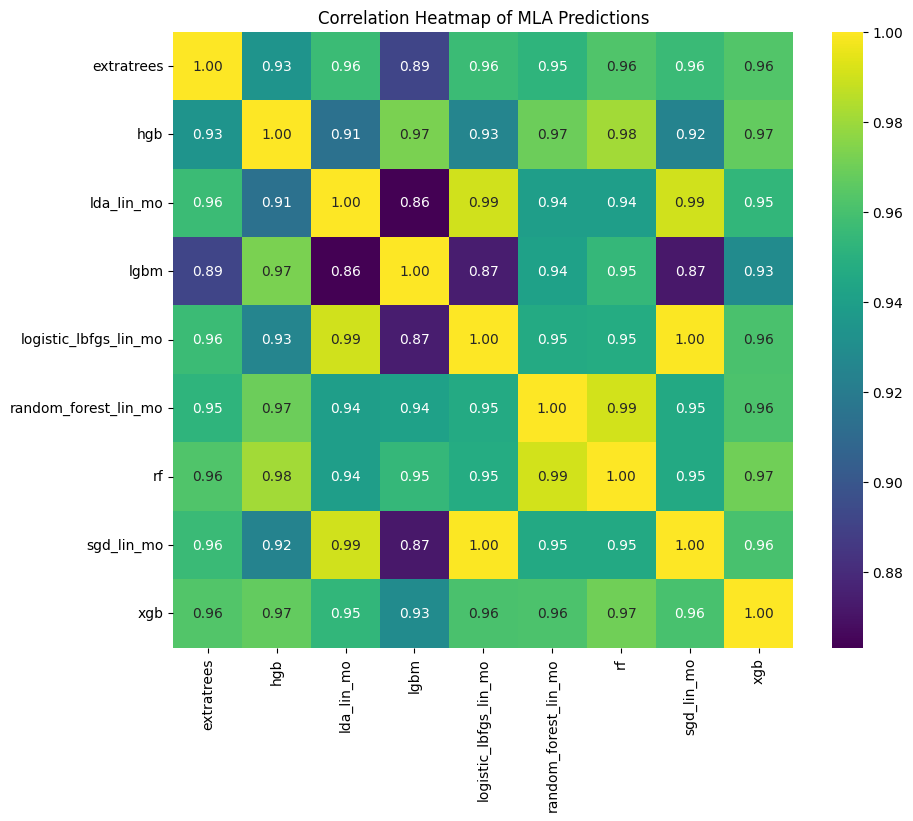

In [7]:


import matplotlib.pyplot as plt
import seaborn as sns

# Create a correlation matrix
corr = X_meta_train.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", cbar=True)
plt.title("Correlation Heatmap of MLA Predictions")
plt.show()



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

meta_model = LogisticRegression(
    C=1.0,
    solver="liblinear",
    random_state=42
)

meta_model.fit(X_meta_train, y_train)

meta_oof_pred = meta_model.predict_proba(X_meta_train)[:, 1]
meta_auc = roc_auc_score(y_train, meta_oof_pred)

print("Meta-model OOF ROC AUC:", meta_auc)


Meta-model OOF ROC AUC: 0.874119877714931


In [60]:
meta_test_pred = meta_model.predict_proba(X_meta_test)[:, 1]
final_pred = (meta_test_pred >= 0.5).astype(int)
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": final_pred
})

os.makedirs("submission", exist_ok=True)
submission.to_csv("submission/stacked_submission.csv", index=False)


In [9]:
pd.Series(
    meta_model.coef_[0],
    index=X_meta_train.columns
).sort_values(ascending=False)


rf                       1.462301
xgb                      1.189912
lgbm                     1.079100
extratrees               0.991572
random_forest_lin_mo     0.574136
hgb                      0.433643
logistic_lbfgs_lin_mo    0.079586
sgd_lin_mo               0.009306
lda_lin_mo              -0.193467
dtype: float64

### Rank features (to imporove)

In [10]:
X_meta_train_rank = X_meta_train.rank(axis=1)
X_meta_test_rank  = X_meta_test.rank(axis=1)

X_meta_train_rank.columns = [c + "_rank" for c in X_meta_train.columns]
X_meta_test_rank.columns  = [c + "_rank" for c in X_meta_test.columns]

X_meta_train = pd.concat([X_meta_train, X_meta_train_rank], axis=1)
X_meta_test  = pd.concat([X_meta_test,  X_meta_test_rank], axis=1)


### Statistical aggregation features

In [11]:
for df in [X_meta_train, X_meta_test]:
    df["mean"] = df[model_names].mean(axis=1)
    df["std"]  = df[model_names].std(axis=1)
    df["min"]  = df[model_names].min(axis=1)
    df["max"]  = df[model_names].max(axis=1)


# Use same folds and train

In [12]:
folds = np.load("./fold_indices.npy", allow_pickle=True)


In [13]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

meta_oof = np.zeros(len(X_meta_train))
meta_test = np.zeros(len(X_meta_test))

for fold, (tr_idx, val_idx) in enumerate(folds):
    print(f"Meta fold {fold+1}")

    X_tr, X_val = X_meta_train.iloc[tr_idx], X_meta_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.01,
        num_leaves=32,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        random_state=42
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )

    meta_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    meta_test += model.predict_proba(X_meta_test)[:, 1] / len(folds)


Meta fold 1
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3182
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

<mark>Error in submissin</mark>

In [14]:
auc = roc_auc_score(y_train, meta_oof)
print(f"STACKING OOF AUC: {auc:.5f}")


STACKING OOF AUC: 0.86278


In [67]:
submission = pd.DataFrame({
    "id": test_ids,      # use correct column
    "target": meta_test
})

submission.to_csv("submission/stacking_submission.csv", index=False)


In [68]:
from sklearn.metrics import roc_auc_score

model_auc = {
    name: roc_auc_score(y_train, X_meta_train[name])
    for name in model_names
}

pd.Series(model_auc).sort_values(ascending=False)


rf                       0.873305
random_forest_lin_mo     0.872581
xgb                      0.871686
hgb                      0.867753
lgbm                     0.861409
extratrees               0.859665
logistic_lbfgs_lin_mo    0.858238
lda_lin_mo               0.857481
sgd_lin_mo               0.857005
dtype: float64

In [15]:
corr = X_meta_train[model_names].corr().abs()


# pruning algorithm based on corr

In [16]:
def correlation_prune(models, aucs, corr, threshold=0.995):
    models = list(models)
    dropped = set()

    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            m1, m2 = models[i], models[j]

            if corr.loc[m1, m2] > threshold:
                drop = m1 if aucs[m1] < aucs[m2] else m2
                dropped.add(drop)

    return [m for m in models if m not in dropped], dropped


In [17]:
model_names_pruned, dropped = correlation_prune(
    model_names, model_auc, corr, threshold=0.995
)

print("Dropped:", dropped)


NameError: name 'model_auc' is not defined

In [72]:
X_meta_train = X_meta_train[model_names_pruned]
X_meta_test  = X_meta_test[model_names_pruned]
model_names  = model_names_pruned


In [18]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score


def blend_auc_loss(weights, preds, y):
    blended = np.dot(preds, weights)
    return -roc_auc_score(y, blended)

pred_matrix = X_meta_train.values
n_models = pred_matrix.shape[1]

init_weights = np.ones(n_models) / n_models
bounds = [(0, 1)] * n_models
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}


result = minimize(
    blend_auc_loss,
    init_weights,
    args=(pred_matrix, y_train.values),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_weights = result.x


weights_df = pd.DataFrame({
    "model": model_names,
    "weight": opt_weights
}).sort_values("weight", ascending=False)

weights_df

final_test_pred = np.dot(X_meta_test.values, opt_weights)


meta_stack_pred = meta_test        # from LGBM stacker
blend_pred      = final_test_pred  # optimized blend

final_pred = 0.7 * meta_stack_pred + 0.3 * blend_pred


print("Blend AUC:", roc_auc_score(y_train, np.dot(X_meta_train.values, opt_weights)))
print("Stack AUC:", roc_auc_score(y_train, meta_oof))



ValueError: All arrays must be of the same length

# Caruana greedy ensemble

In [19]:
oof_preds = X_meta_train[model_names].values
test_preds = X_meta_test[model_names].values



from sklearn.metrics import roc_auc_score

def greedy_ensemble(oof_preds, y, max_iter=50):
    n_models = oof_preds.shape[1]
    selected = []
    ensemble_pred = np.zeros(len(y))

    for _ in range(max_iter):
        best_score = -np.inf
        best_model = None

        for i in range(n_models):
            trial = (
                ensemble_pred * len(selected) + oof_preds[:, i]
            ) / (len(selected) + 1)

            score = roc_auc_score(y, trial)

            if score > best_score:
                best_score = score
                best_model = i

        selected.append(best_model)
        ensemble_pred = (
            ensemble_pred * (len(selected) - 1) + oof_preds[:, best_model]
        ) / len(selected)

    return selected


selected_models = greedy_ensemble(oof_preds, y_train.values)


final_oof = np.mean(oof_preds[:, selected_models], axis=1)
final_test = np.mean(test_preds[:, selected_models], axis=1)


from sklearn.model_selection import StratifiedKFold

def stability_score(preds, y, folds):
    scores = []
    for tr, val in folds:
        scores.append(roc_auc_score(y[val], preds[val]))
    return np.mean(scores), np.std(scores)



def dropout_test(oof_preds, y):
    base = roc_auc_score(y, oof_preds.mean(axis=1))
    bad = []

    for i in range(oof_preds.shape[1]):
        reduced = np.delete(oof_preds, i, axis=1).mean(axis=1)
        score = roc_auc_score(y, reduced)
        if score >= base:
            bad.append(i)

    return bad


**1️⃣ Inspect the greedy selection (VERY important)**
- Models selected many times → strong + stable
- Models selected 0 times → useless for ensemble
- Models selected once → weak contributors

In [20]:
from collections import Counter

counts = Counter(selected_models)

pd.DataFrame({
    "model": [model_names[i] for i in counts.keys()],
    "times_selected": counts.values()
}).sort_values("times_selected", ascending=False)


,model,times_selected
0,rf,19
1,xgb,16
2,lgbm,8
3,extratrees,5
4,random_forest_lin_mo,1
5,hgb,1


Keep only models used by greedy

In [21]:
keep_idx = sorted(set(selected_models))

oof_pruned = oof_preds[:, keep_idx]
test_pruned = test_preds[:, keep_idx]

kept_models = [model_names[i] for i in keep_idx]
print("Kept models:", kept_models)

# 3️⃣ Dropout test on pruned set (anti-LB trick)
bad = dropout_test(oof_pruned, y_train.values)
print("Dropout models:", bad)
# Remove toxic models
if bad:
    good_idx = [i for i in range(oof_pruned.shape[1]) if i not in bad]
    oof_pruned = oof_pruned[:, good_idx]
    test_pruned = test_pruned[:, good_idx]

# 4️⃣ Stability score (THIS decides final submission)
mean_auc, std_auc = stability_score(
    preds=oof_pruned.mean(axis=1),
    y=y_train.values,
    folds=folds
)

print(f"Stability AUC: {mean_auc:.5f} ± {std_auc:.5f}")


final_oof_rank  = pd.Series(oof_pruned.mean(axis=1)).rank().values
final_test_rank = pd.Series(test_pruned.mean(axis=1)).rank().values

print("Ranked AUC:", roc_auc_score(y_train, final_oof_rank))


Kept models: ['extratrees', 'hgb', 'lgbm', 'random_forest_lin_mo', 'rf', 'xgb']
Dropout models: [1, 3]
Stability AUC: 0.87558 ± 0.01904
Ranked AUC: 0.8739814015914101


Sanity checks before submission

In [22]:
print("Greedy OOF AUC:", roc_auc_score(y_train, final_oof))
print("Pruned OOF AUC:", roc_auc_score(y_train, oof_pruned.mean(axis=1)))
print("Ranked OOF AUC:", roc_auc_score(y_train, final_oof_rank))


Greedy OOF AUC: 0.8745459580949948
Pruned OOF AUC: 0.8739814015914101
Ranked OOF AUC: 0.8739814015914101


In [23]:
# 1️⃣ Final ensemble (mean of pruned models)
final_oof = oof_pruned.mean(axis=1)
final_test = test_pruned.mean(axis=1)

# 2️⃣ Optional: rank-average for stability
final_oof_rank  = pd.Series(final_oof).rank().values
final_test_rank = pd.Series(final_test).rank().values

# 3️⃣ LB-safe blend (weighted average)
final_test_safe = 0.6 * final_test + 0.4 * final_test_rank

# 4️⃣ Check CV
from sklearn.metrics import roc_auc_score
print("Final OOF AUC:", roc_auc_score(y_train.values, final_oof))
print("Final OOF ranked AUC:", roc_auc_score(y_train.values, final_oof_rank))


Final OOF AUC: 0.8739814015914101
Final OOF ranked AUC: 0.8739814015914101


In [24]:
submission = pd.DataFrame({
    "id": test_ids,
    "target": final_test_safe
})

submission.to_csv("lb_safe_submission.csv", index=False)


In [25]:
# Some useful parameters which will come in handy later on
from sklearn.model_selection import KFold


ntrain = X_train.shape[0]
ntest = X_test.shape[0]
SEED = 0 # for reproducibility
NFOLDS = 5 # set folds for out-of-fold prediction
kf = KFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)

# Class to extend the Sklearn classifier
class SklearnHelper(object):
    def __init__(self, clf, seed=0, params=None):
        params['random_state'] = seed
        self.clf = clf(**params)

    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)

    def predict(self, x):
        return self.clf.predict(x)
    
    def fit(self,x,y):
        return self.clf.fit(x,y)
    
    def feature_importances(self,x,y):
        print(self.clf.fit(x,y).feature_importances_)
    
# Class to extend XGboost classifer

In [26]:
import numpy as np

def get_oof(clf, x_train, y_train, x_test):
    ntrain = x_train.shape[0]
    ntest = x_test.shape[0]
    
    oof_train = np.zeros(ntrain)
    oof_test = np.zeros(ntest)
    oof_test_skf = np.empty((NFOLDS, ntest))
    
    for i, (train_index, test_index) in enumerate(kf.split(x_train)):
        x_tr = x_train.iloc[train_index]
        y_tr = y_train.iloc[train_index]
        x_te = x_train.iloc[test_index]
        
        clf.fit(x_tr, y_tr)
        
        oof_train[test_index] = clf.predict(x_te)
        oof_test_skf[i, :] = clf.predict(x_test)
    
    oof_test[:] = oof_test_skf.mean(axis=0)
    return oof_train, oof_test


In [27]:
# Put in our parameters for said classifiers
# Random Forest parameters
rf_params = {
    'n_jobs': -1,
    'n_estimators': 500,
     'warm_start': True, 
     #'max_features': 0.2,
    'max_depth': 6,
    'min_samples_leaf': 2,
    'max_features' : 'sqrt',
    'verbose': 0
}

# Extra Trees Parameters
et_params = {
    'n_jobs': -1,
    'n_estimators':500,
    #'max_features': 0.5,
    'max_depth': 8,
    'min_samples_leaf': 2,
    'verbose': 0
}

# AdaBoost parameters
ada_params = {
    'n_estimators': 500,
    'learning_rate' : 0.75
}

# Gradient Boosting parameters
gb_params = {
    'n_estimators': 500,
     #'max_features': 0.2,
    'max_depth': 5,
    'min_samples_leaf': 2,
    'verbose': 0
}

# Support Vector Classifier parameters 
svc_params = {
    'kernel' : 'linear',
    'C' : 0.025
    }

In [29]:


# Create 5 objects that represent our 4 models
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC


rf = SklearnHelper(clf=RandomForestClassifier, seed=SEED, params=rf_params)
et = SklearnHelper(clf=ExtraTreesClassifier, seed=SEED, params=et_params)
ada = SklearnHelper(clf=AdaBoostClassifier, seed=SEED, params=ada_params)
gb = SklearnHelper(clf=GradientBoostingClassifier, seed=SEED, params=gb_params)
svc = SklearnHelper(clf=SVC, seed=SEED, params=svc_params)

**Output of the First level Predictions**

We now feed the training and test data into our 5 base classifiers and use the Out-of-Fold prediction function we defined earlier to generate our first level predictions. Allow a handful of minutes for the chunk of code below to run.

In [30]:
# Create our OOF train and test predictions. These base results will be used as new features
et_oof_train, et_oof_test = get_oof(et, X_train, y_train, X_test) # Extra Trees
rf_oof_train, rf_oof_test = get_oof(rf,X_train, y_train, X_test) # Random Forest
ada_oof_train, ada_oof_test = get_oof(ada, X_train, y_train, X_test) # AdaBoost 
gb_oof_train, gb_oof_test = get_oof(gb,X_train, y_train, X_test) # Gradient Boost
svc_oof_train, svc_oof_test = get_oof(svc,X_train, y_train, X_test) # Support Vector Classifier

print("Training is complete")

Training is complete


**Second-Level Predictions from the First-level Output**
Having now obtained our first-level predictions, one can think of it as essentially building a new set of features to be used as training data for the next classifier. As per the code below, we are therefore having as our new columns the first-level predictions from our earlier classifiers and we train the next classifier on this.

In [31]:


base_predictions_train = pd.DataFrame( {'RandomForest': rf_oof_train.ravel(),
     'ExtraTrees': et_oof_train.ravel(),
     'AdaBoost': ada_oof_train.ravel(),
      'GradientBoost': gb_oof_train.ravel()
    })
base_predictions_train.head()



,RandomForest,ExtraTrees,AdaBoost,GradientBoost
0,0.0,0.0,0.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
4,0.0,0.0,0.0,0.0


In [32]:
import plotly.graph_objects as go
import plotly.offline as py

# If running in a Jupyter notebook
py.init_notebook_mode(connected=True)

# Then your heatmap code
data = [
    go.Heatmap(
        z=base_predictions_train.astype(float).corr().values,
        x=base_predictions_train.columns.values,
        y=base_predictions_train.columns.values,
        colorscale='Viridis',
        showscale=True,
        reversescale=True
    )
]

py.iplot(data, filename='labelled-heatmap')


In [33]:
x_train = np.concatenate([
    et_oof_train.reshape(-1, 1),
    rf_oof_train.reshape(-1, 1),
    ada_oof_train.reshape(-1, 1),
    gb_oof_train.reshape(-1, 1),
    svc_oof_train.reshape(-1, 1)
], axis=1)

x_test = np.concatenate([
    et_oof_test.reshape(-1, 1),
    rf_oof_test.reshape(-1, 1),
    ada_oof_test.reshape(-1, 1),
    gb_oof_test.reshape(-1, 1),
    svc_oof_test.reshape(-1, 1)
], axis=1)


In [34]:
gbm = xgb.XGBClassifier(
    #learning_rate = 0.02,
 n_estimators= 2000,
 max_depth= 4,
 min_child_weight= 2,
 #gamma=1,
 gamma=0.9,                        
 subsample=0.8,
 colsample_bytree=0.8,
 objective= 'binary:logistic',
 nthread= -1,
 scale_pos_weight=1).fit(x_train, y_train)
predictions = gbm.predict(x_test)

In [35]:
#Machine Learning Algorithm (MLA) Selection and Initialization
from sklearn import ensemble
from sklearn import gaussian_process
from sklearn import linear_model
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import svm
from sklearn import tree
from sklearn import discriminant_analysis
from xgboost import XGBClassifier


MLA = [
    #Ensemble Methods
    ensemble.AdaBoostClassifier(),
    ensemble.BaggingClassifier(),
    ensemble.ExtraTreesClassifier(),
    ensemble.GradientBoostingClassifier(),
    ensemble.RandomForestClassifier(),

    #Gaussian Processes
    gaussian_process.GaussianProcessClassifier(),
    
    #GLM
    linear_model.LogisticRegressionCV(),
    linear_model.PassiveAggressiveClassifier(),
    linear_model.RidgeClassifierCV(),
    linear_model.SGDClassifier(),
    linear_model.Perceptron(),
    
    #Navies Bayes
    naive_bayes.BernoulliNB(),
    naive_bayes.GaussianNB(),
    
    #Nearest Neighbor
    neighbors.KNeighborsClassifier(),
    
    #SVM
    svm.SVC(probability=True),
    svm.NuSVC(probability=True),
    svm.LinearSVC(),
    
    #Trees    
    tree.DecisionTreeClassifier(),
    tree.ExtraTreeClassifier(),
    
    #Discriminant Analysis
    discriminant_analysis.LinearDiscriminantAnalysis(),
    discriminant_analysis.QuadraticDiscriminantAnalysis(),

    
    #xgboost: http://xgboost.readthedocs.io/en/latest/model.html
    XGBClassifier()    
    ]

In [40]:
from sklearn import model_selection
import pandas as pd

cv_split = model_selection.ShuffleSplit(
    n_splits=10, test_size=0.3, train_size=0.6, random_state=0
)

# Create table to compare MLA metrics
MLA_columns = [
    'MLA Name', 'MLA Parameters',
    'MLA Train Accuracy Mean', 'MLA Test Accuracy Mean',
    'MLA Test Accuracy 3*STD', 'MLA Time'
]
MLA_compare = pd.DataFrame(columns=MLA_columns)

# Create table to compare MLA predictions
MLA_predict = pd.DataFrame(index=y_train.index)

# Index through MLA and save performance to table
row_index = 0
for alg in MLA:

    # Set name and parameters
    MLA_name = alg.__class__.__name__
    MLA_compare.loc[row_index, 'MLA Name'] = MLA_name
    MLA_compare.loc[row_index, 'MLA Parameters'] = str(alg.get_params())

    # Score model with cross-validation
    cv_results = model_selection.cross_validate(
        alg, X_train, y_train, cv=cv_split, return_train_score=True
    )

    MLA_compare.loc[row_index, 'MLA Time'] = cv_results['fit_time'].mean()
    MLA_compare.loc[row_index, 'MLA Train Accuracy Mean'] = cv_results['train_score'].mean()
    MLA_compare.loc[row_index, 'MLA Test Accuracy Mean'] = cv_results['test_score'].mean()
    MLA_compare.loc[row_index, 'MLA Test Accuracy 3*STD'] = cv_results['test_score'].std() * 3

    # Save MLA predictions
    alg.fit(X_train, y_train)
    MLA_predict[MLA_name] = alg.predict(X_train)

    row_index += 1

#print and sort table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.sort_values.html
MLA_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending = False, inplace = True)
MLA_compare

,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Test Accuracy Mean,MLA Test Accuracy 3*STD,MLA Time
3,GradientBoostingClassifier,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",0.89588,0.826119,0.052073,0.067656
4,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.935768,0.822761,0.066837,0.070897
2,ExtraTreesClassifier,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.935768,0.820896,0.070264,0.053168
0,AdaBoostClassifier,"{'algorithm': 'SAMME.R', 'estimator': None, 'l...",0.842135,0.817164,0.069367,0.060092
21,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.93221,0.815672,0.064538,0.030297
15,NuSVC,"{'break_ties': False, 'cache_size': 200, 'clas...",0.825655,0.81306,0.053322,0.024404
1,BaggingClassifier,"{'bootstrap': True, 'bootstrap_features': Fals...",0.927715,0.809701,0.070442,0.014187
6,LogisticRegressionCV,"{'Cs': 10, 'class_weight': None, 'cv': None, '...",0.823408,0.808209,0.067573,0.085426
14,SVC,"{'C': 1.0, 'break_ties': False, 'cache_size': ...",0.821161,0.806343,0.052133,0.022225
17,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",0.935768,0.802985,0.065425,0.002405


Text(0, 0.5, 'Algorithm')

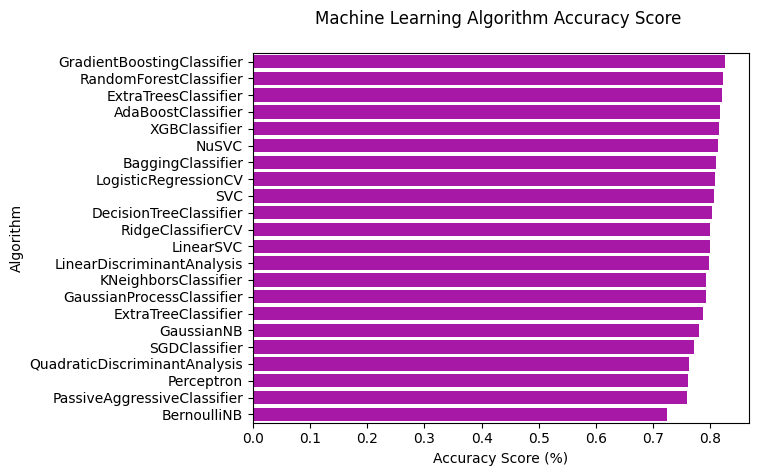

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

#barplot using https://seaborn.pydata.org/generated/seaborn.barplot.html
sns.barplot(x='MLA Test Accuracy Mean', y = 'MLA Name', data = MLA_compare, color = 'm')

#prettify using pyplot: https://matplotlib.org/api/pyplot_api.html
plt.title('Machine Learning Algorithm Accuracy Score \n')
plt.xlabel('Accuracy Score (%)')
plt.ylabel('Algorithm')

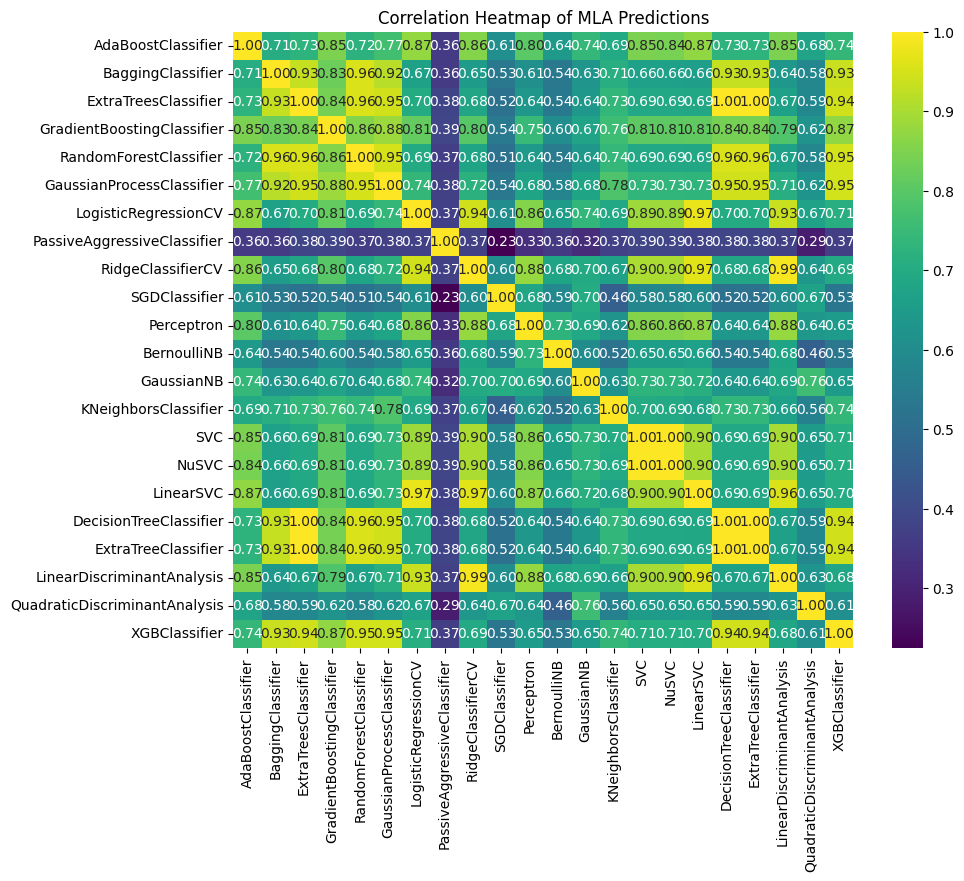

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a correlation matrix
corr = MLA_predict.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", cbar=True)
plt.title("Correlation Heatmap of MLA Predictions")
plt.show()


In [50]:
from sklearn import ensemble, model_selection, linear_model, naive_bayes, neighbors, svm, gaussian_process
from xgboost import XGBClassifier

# Voting estimators
vote_est = [
    ('ada', ensemble.AdaBoostClassifier()),
    ('bc', ensemble.BaggingClassifier()),
    ('etc', ensemble.ExtraTreesClassifier()),
    ('gbc', ensemble.GradientBoostingClassifier()),
    ('rfc', ensemble.RandomForestClassifier()),

    ('gpc', gaussian_process.GaussianProcessClassifier()),
    ('lr', linear_model.LogisticRegressionCV()),
    ('bnb', naive_bayes.BernoulliNB()),
    ('gnb', naive_bayes.GaussianNB()),
    ('knn', neighbors.KNeighborsClassifier()),
    ('svc', svm.SVC(probability=True)),
    ('xgb', XGBClassifier())
]

# -----------------------------
# Hard Voting
# -----------------------------
vote_hard = ensemble.VotingClassifier(estimators=vote_est, voting='hard')
vote_hard_cv = model_selection.cross_validate(
    vote_hard, X_train, y_train, cv=cv_split, return_train_score=True
)
vote_hard.fit(X_train, y_train)

print("Hard Voting Training w/bin score mean: {:.2f}".format(vote_hard_cv['train_score'].mean()*100)) 
print("Hard Voting Test w/bin score mean: {:.2f}".format(vote_hard_cv['test_score'].mean()*100))
print("Hard Voting Test w/bin score 3*std: +/- {:.2f}".format(vote_hard_cv['test_score'].std()*100*3))
print('-'*10)

# -----------------------------
# Soft Voting
# -----------------------------
# Filter estimators to include only models with predict_proba
vote_est_soft = [(name, model) for name, model in vote_est if hasattr(model, "predict_proba")]

vote_soft = ensemble.VotingClassifier(estimators=vote_est_soft, voting='soft')
vote_soft_cv = model_selection.cross_validate(
    vote_soft, X_train, y_train, cv=cv_split, return_train_score=True
)
vote_soft.fit(X_train, y_train)

print("Soft Voting Training w/bin score mean: {:.2f}".format(vote_soft_cv['train_score'].mean()*100)) 
print("Soft Voting Test w/bin score mean: {:.2f}".format(vote_soft_cv['test_score'].mean()*100))
print("Soft Voting Test w/bin score 3*std: +/- {:.2f}".format(vote_soft_cv['test_score'].std()*100*3))
print('-'*10)


Hard Voting Training w/bin score mean: 90.97
Hard Voting Test w/bin score mean: 82.87
Hard Voting Test w/bin score 3*std: +/- 6.34
----------
Soft Voting Training w/bin score mean: 91.27
Soft Voting Test w/bin score mean: 82.72
Soft Voting Test w/bin score 3*std: +/- 7.66
----------
